# **Import Library**


In [1]:
import csv
import re
import string
import urllib.request
from io import StringIO
from pathlib import Path

import emoji
import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import requests
import seaborn as sns
import tensorflow as tf
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.svm import SVC
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Bidirectional, Dense, Dropout, Embedding, LSTM
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from wordcloud import WordCloud

pd.options.mode.chained_assignment = None

seed = 42
np.random.seed(seed)
tf.random.set_seed(seed)


I0000 00:00:1774960812.982763  260031 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1774960813.045914  260031 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774960814.230181  260031 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)


True

# **Loading Dataset**


In [3]:
df = pd.read_csv('Stockbit_ulasan_aplikasi.csv')
df.head()


,Review
0,Keren. Sangat membantu. Tapi sayangnya belum a...
1,"min,abis update kok akun ke logout,saya kan bi..."
2,"tiba tiba akun stockbit saya logout sendiri, k..."
3,"akun saya belom aktif juga,... sudah 3 Minggu,..."
4,"tidak bisa buka aplikasi nya, ada notif tolong..."


In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 17171 entries, 0 to 17170
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Review  17171 non-null  str  
dtypes: str(1)
memory usage: 134.3 KB


In [5]:
df.isnull().sum()


Review    0
dtype: int64

In [6]:
df.duplicated().sum()


np.int64(3653)

In [7]:
clean_df = df.dropna().drop_duplicates().copy()
clean_df.info()


<class 'pandas.DataFrame'>
Index: 13518 entries, 0 to 17170
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Review  13518 non-null  str  
dtypes: str(1)
memory usage: 211.2 KB


# **Preprocessing**



In [8]:
slangwords = {
    'gak': 'tidak',
    'nggak': 'tidak',
    'nya': 'itu',
    'yaa': 'ya',
    'sih': 'saja',
    'ku': 'saya',
    'lo': 'kamu',
    'loi': 'kamu',
    'loh': 'loh',
    'wa': 'saya',
    'g': 'tidak',
    'ga': 'tidak',
    'woy': 'hei',
    'ye': 'iya',
    'kayak': 'seperti',
    'gpp': 'tidak apa-apa',
    'bgt': 'banget',
    'biasaaja': 'biasa saja',
    'tq': 'terima kasih',
    'pls': 'mohon',
    'sm': 'sama',
    'nm': 'nama',
    'btw': 'ngomong-ngomong',
    'klo': 'kalau',
    'cuy': 'kawan',
    'ribet': 'rumit',
    'anjir': 'anjing',
    'anjay': 'anjing',
    'parah': 'sangat',
    'gampang': 'mudah',
    'cakep': 'bagus',
    'dikit': 'sedikit',
    'udh': 'sudah',
    'ato': 'atau',
    'dr': 'dari',
    'krn': 'karena',
    'skrg': 'sekarang',
    'buat': 'untuk',
    'yg': 'yang',
    'dlu': 'dulu',
    'kyc': 'verifikasi identitas',
    'wd': 'penarikan',
    'depo': 'deposit',
    'tranding': 'trading',
    'apk': 'aplikasi',
    'trs': 'terus',
    'pdhal': 'padahal',
    'lg': 'lagi',
    'gmn': 'bagaimana',
    'ampe': 'sampai',
    'jd': 'jadi',
    'kek': 'seperti',
    'dpt': 'dapat',
    'lgi': 'lagi',
    'tpi': 'tapi',
    'mnrt': 'menurut',
    'skli': 'sekali',
    'pkoknya': 'pokoknya',
    'trus': 'terus',
    'wkwk': 'tertawa',
    'wkwkwk': 'tertawa',
    'bs': 'bisa',
    'tp': 'tapi',
    'kalo': 'kalau',
    'gua': 'saya'
}

base_stopwords = set(stopwords.words('indonesian')) | set(stopwords.words('english'))
custom_stopwords = {'iya', 'yaa', 'gak', 'nya', 'na', 'sih', 'ku', 'di', 'ga', 'ya', 'gaa', 'loh', 'kah', 'woi', 'woii', 'woy'}
all_stopwords = base_stopwords | custom_stopwords


def contains_emoji(text):
    return any(char in emoji.EMOJI_DATA for char in str(text))



def normalize_slang(tokens):
    return [slangwords.get(token, token) for token in tokens]



def preprocess_text(text):
    text = str(text)
    if contains_emoji(text):
        return None

    text = re.sub(r'@[A-Za-z0-9_]+', ' ', text)
    text = re.sub(r'#[A-Za-z0-9_]+', ' ', text)
    text = re.sub(r'RT[\s]+', ' ', text)
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'\d+', ' ', text)
    text = text.replace('\n', ' ').lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()

    tokens = word_tokenize(text)
    tokens = normalize_slang(tokens)
    tokens = [token for token in tokens if token not in all_stopwords and len(token) > 1]

    if not tokens:
        return None

    return ' '.join(tokens)


In [9]:
jumlah_data_awal = len(clean_df)
clean_df['text_akhir'] = clean_df['Review'].apply(preprocess_text)
clean_df = clean_df.dropna(subset=['text_akhir']).reset_index(drop=True)

print(f'Jumlah data sebelum preprocessing: {jumlah_data_awal}')
print(f'Jumlah data setelah preprocessing: {len(clean_df)}')


Jumlah data sebelum preprocessing: 13518
Jumlah data setelah preprocessing: 12350


In [10]:
clean_df[['Review', 'text_akhir']].head()


,Review,text_akhir
0,Keren. Sangat membantu. Tapi sayangnya belum a...,keren membantu sayangnya trailing stop ayo rum...
1,"min,abis update kok akun ke logout,saya kan bi...",minabis update akun logoutsaya bikin akun emai...
2,"tiba tiba akun stockbit saya logout sendiri, k...",akun stockbit logout coba login masuk coba lup...
3,"akun saya belom aktif juga,... sudah 3 Minggu,...",akun belom aktif minggu bukti chat bantuan sto...
4,"tidak bisa buka aplikasi nya, ada notif tolong...",buka aplikasi notif tolong nonaktifkan usb deb...


In [11]:
clean_df[['text_akhir']].sample(5, random_state=42)


,text_akhir
7631,sb beres duit ilang laporan
8260,mantap belajar saham
5196,ngerti main beli aja butuh mentor kasih tau ma...
1747,cs bales pesan emng ber jam jam guni busett da...
3532,error jam pasar berulang error


# **Pelabelan**
Pelabelan dilakukan secara lexicon-based untuk menghasilkan label awal positif, negatif, dan netral dari teks yang sudah dipreproses.


In [12]:
lexicon_positive = {}
response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_positive.csv', timeout=30)
response.raise_for_status()
reader = csv.reader(StringIO(response.text), delimiter=',')
for row in reader:
    lexicon_positive[row[0]] = int(row[1])

lexicon_negative = {}
response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_negative.csv', timeout=30)
response.raise_for_status()
reader = csv.reader(StringIO(response.text), delimiter=',')
for row in reader:
    lexicon_negative[row[0]] = int(row[1])


def sentiment_analysis_lexicon_indonesia(text):
    score = 0

    for word in text.split():
        if word in lexicon_positive:
            score += lexicon_positive[word]
        elif word in lexicon_negative:
            score += lexicon_negative[word]

    if score > 0:
        polarity = 'positive'
    elif score < 0:
        polarity = 'negative'
    else:
        polarity = 'neutral'

    return score, polarity


In [13]:
results = clean_df['text_akhir'].apply(sentiment_analysis_lexicon_indonesia)
results = list(zip(*results))
clean_df['polarity_score'] = results[0]
clean_df['polarity'] = results[1]
print(clean_df['polarity'].value_counts())


polarity
positive    7059
negative    3047
neutral     2244
Name: count, dtype: int64


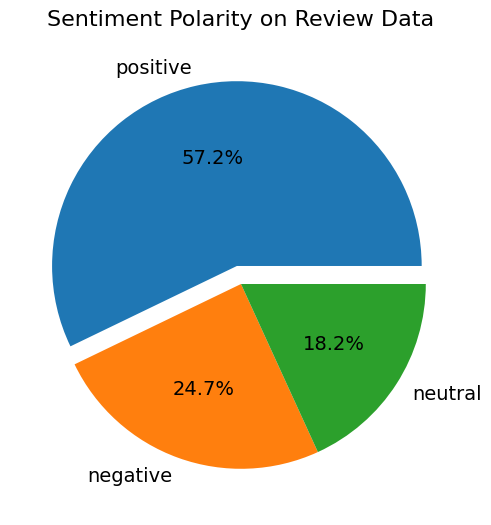

In [14]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 6))

sizes = [count for count in clean_df['polarity'].value_counts()]
labels = list(clean_df['polarity'].value_counts().index)

# Explode otomatis sesuai jumlah kategori
explode = [0.1] + [0] * (len(labels) - 1)

ax.pie(x=sizes, labels=labels, autopct='%1.1f%%', explode=explode, textprops={'fontsize': 14})
ax.set_title('Sentiment Polarity on Review Data', fontsize=16, pad=20)

plt.show()

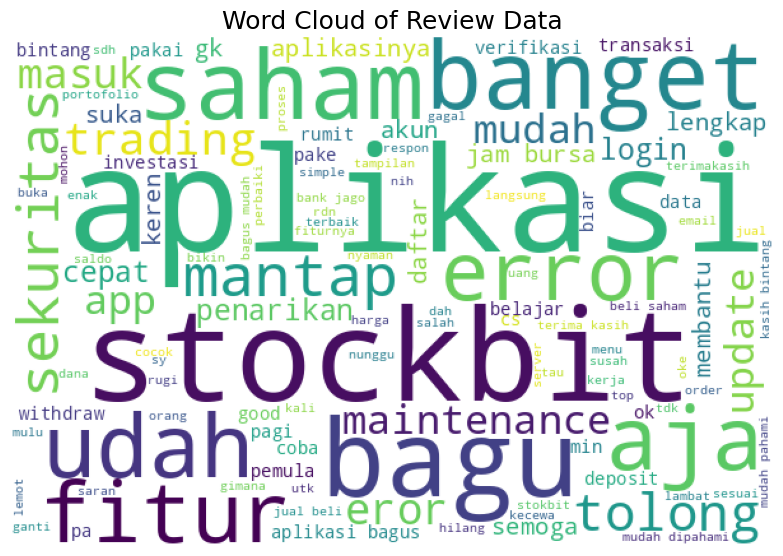

In [15]:
pd.set_option('display.max_colwidth', 3000)

positive_tweets = clean_df[clean_df['polarity'] == 'positive'][['text_akhir', 'polarity_score', 'polarity']]
positive_tweets = positive_tweets.sort_values(by='polarity_score', ascending=False).reset_index(drop=True)
positive_tweets.index += 1

negative_tweets = clean_df[clean_df['polarity'] == 'negative'][['text_akhir', 'polarity_score', 'polarity']]
negative_tweets = negative_tweets.sort_values(by='polarity_score', ascending=True).head(10).reset_index(drop=True)
negative_tweets.index += 1

list_words = ' '.join(clean_df['text_akhir'].astype(str))
wordcloud = WordCloud(width=600, height=400, background_color='white', min_font_size=10).generate(list_words)

fig, ax = plt.subplots(figsize=(8, 6))
ax.set_title('Word Cloud of Review Data', fontsize=18)
ax.grid(False)
ax.imshow(wordcloud)
fig.tight_layout(pad=0)
ax.axis('off')
plt.show()


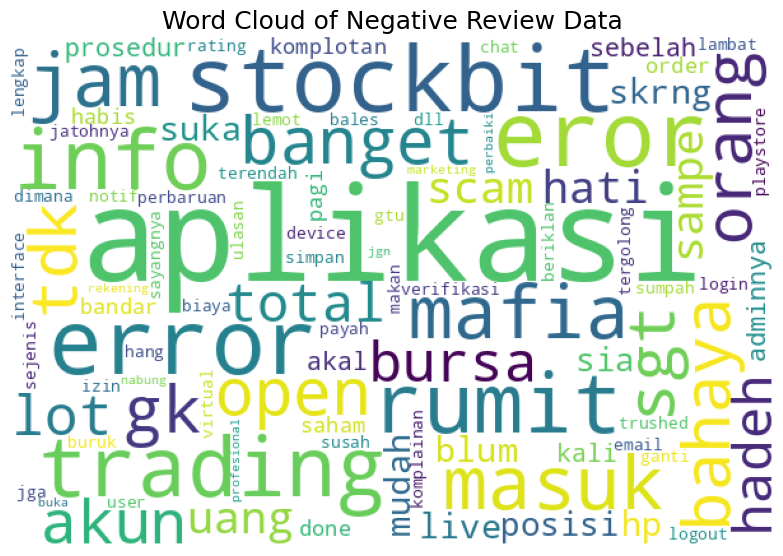

In [16]:
list_words = ' '.join(negative_tweets['text_akhir'].astype(str))
wordcloud = WordCloud(width=600, height=400, background_color='white', min_font_size=10).generate(list_words)

fig, ax = plt.subplots(figsize=(8, 6))
ax.set_title('Word Cloud of Negative Review Data', fontsize=18)
ax.grid(False)
ax.imshow(wordcloud)
fig.tight_layout(pad=0)
ax.axis('off')
plt.show()


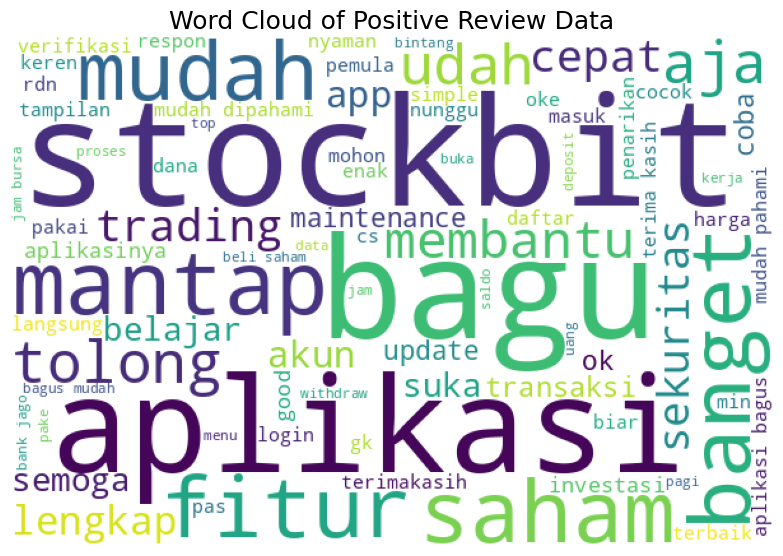

In [17]:
list_words = ' '.join(positive_tweets['text_akhir'].astype(str))
wordcloud = WordCloud(width=600, height=400, background_color='white', min_font_size=10).generate(list_words)

fig, ax = plt.subplots(figsize=(8, 6))
ax.set_title('Word Cloud of Positive Review Data', fontsize=18)
ax.grid(False)
ax.imshow(wordcloud)
fig.tight_layout(pad=0)
ax.axis('off')
plt.show()


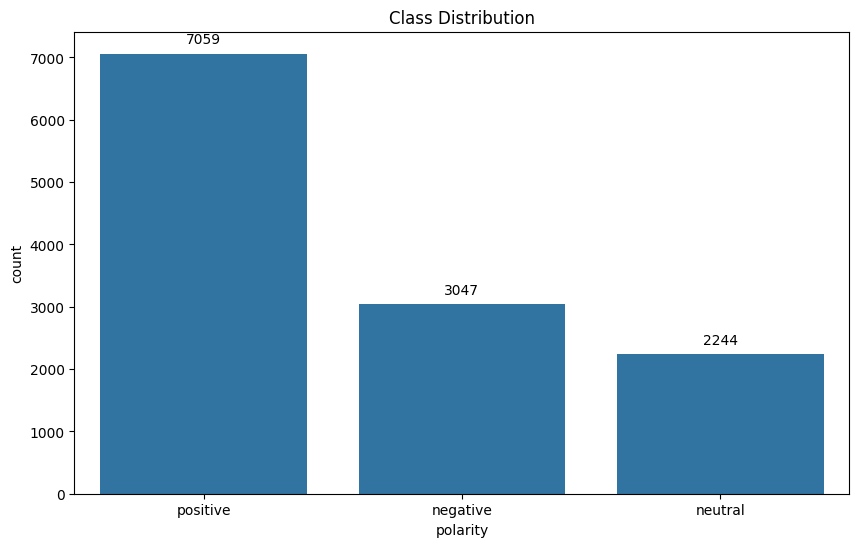

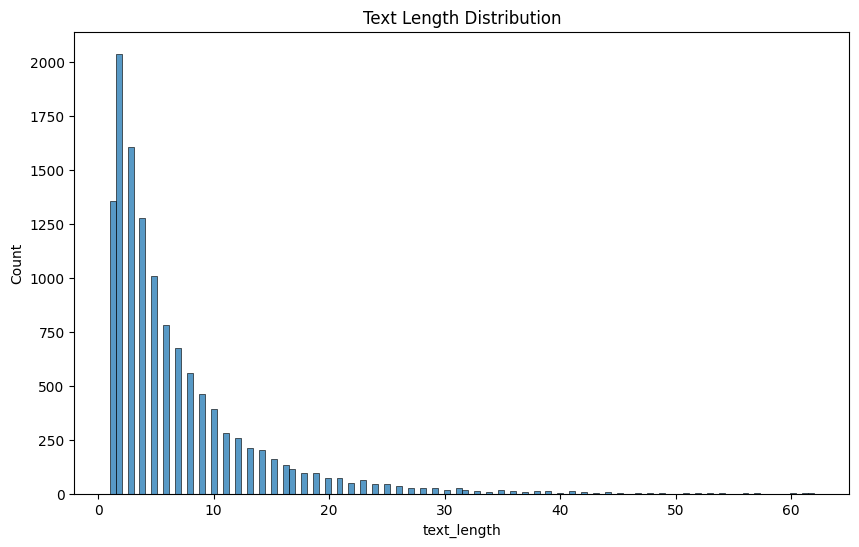

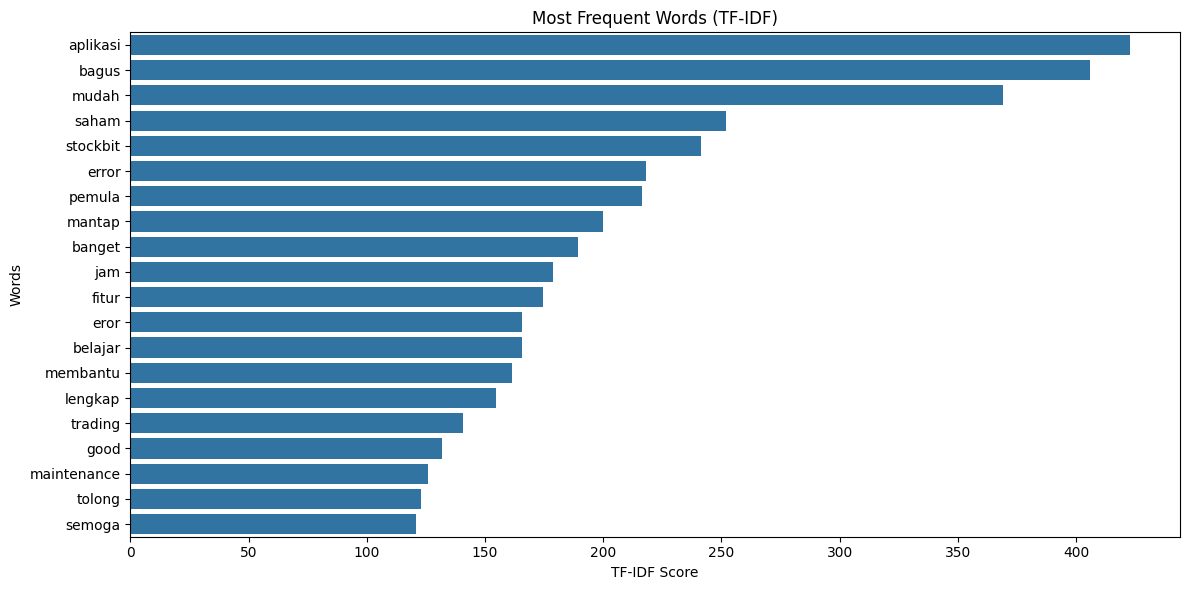

In [18]:
plt.figure(figsize=(10, 6))
class_dist_plot = sns.countplot(x='polarity', data=clean_df)
plt.title('Class Distribution')

for p in class_dist_plot.patches:
    class_dist_plot.annotate(
        format(p.get_height(), '.0f'),
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha='center',
        va='center',
        xytext=(0, 10),
        textcoords='offset points'
    )
plt.show()

plt.figure(figsize=(10, 6))
clean_df['text_length'] = clean_df['text_akhir'].apply(lambda x: len(x.split()))
sns.histplot(clean_df['text_length'])
plt.title('Text Length Distribution')
plt.show()

plt.figure(figsize=(12, 6))
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(clean_df['text_akhir'])
tfidf_sum = np.array(X.sum(axis=0)).flatten()
feature_names = vectorizer.get_feature_names_out()

tfidf_df = pd.DataFrame({'word': feature_names, 'jumlah': tfidf_sum})
tfidf_df = tfidf_df.sort_values('jumlah', ascending=False).head(20)

sns.barplot(x='jumlah', y='word', data=tfidf_df)
plt.title('Most Frequent Words (TF-IDF)')
plt.xlabel('TF-IDF Score')
plt.ylabel('Words')
plt.tight_layout()
plt.show()


# **Modeling**


In [19]:
fitur_teks = clean_df['text_akhir'].astype(str)
label_map = {'neutral': 0, 'negative': 1, 'positive': 2}
inverse_label_map = {value: key for key, value in label_map.items()}
target_labels = [0, 1, 2]
target_names = [inverse_label_map[label] for label in target_labels]
label_sentimen = clean_df['polarity'].map(label_map).astype(int)

vektor_tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), max_df=0.9)
fitur_tfidf = vektor_tfidf.fit_transform(fitur_teks)


## Random Forest
Pelatihan: RF, Ekstraksi Fitur: TF-IDF, Pembagian Data: 70/30


In [20]:
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    fitur_tfidf,
    label_sentimen,
    test_size=0.3,
    stratify=label_sentimen,
    random_state=42,
)

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1,
)
rf_model.fit(X_train_rf, y_train_rf)

y_pred_train_rf = rf_model.predict(X_train_rf)
y_pred_test_rf = rf_model.predict(X_test_rf)

acc_train_rf = accuracy_score(y_train_rf, y_pred_train_rf)
acc_test_rf = accuracy_score(y_test_rf, y_pred_test_rf)
f1_rf = f1_score(y_test_rf, y_pred_test_rf, average='macro')

print(f'Akurasi Training Set (Random Forest): {acc_train_rf:.2%}')
print(f'Akurasi Testing Set (Random Forest): {acc_test_rf:.2%}')
print(f'F1 Macro (Random Forest): {f1_rf:.2%}')
print('\nClassification Report (Random Forest - Testing Set):')
print(classification_report(y_test_rf, y_pred_test_rf, labels=target_labels, target_names=target_names))


Akurasi Training Set (Random Forest): 99.84%
Akurasi Testing Set (Random Forest): 85.59%
F1 Macro (Random Forest): 83.15%

Classification Report (Random Forest - Testing Set):
              precision    recall  f1-score   support

     neutral       0.80      0.85      0.82       673
    negative       0.85      0.71      0.78       914
    positive       0.88      0.92      0.90      2118

    accuracy                           0.86      3705
   macro avg       0.84      0.83      0.83      3705
weighted avg       0.86      0.86      0.85      3705



## SVM dengan GridSearchCV
Pelatihan: SVM, Ekstraksi Fitur: TF-IDF, Pembagian Data: 80/20


In [21]:
X_train_svm, X_test_svm, y_train_svm, y_test_svm = train_test_split(
    fitur_tfidf,
    label_sentimen,
    test_size=0.2,
    random_state=42,
    stratify=label_sentimen,
)

param_grid = [
    {'kernel': ['linear'], 'C': [0.1, 1, 10, 100]},
    {'kernel': ['rbf'], 'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto']},
]

svm_search = GridSearchCV(
    estimator=SVC(),
    param_grid=param_grid,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1,
    verbose=1,
)
svm_search.fit(X_train_svm, y_train_svm)

svm_model = svm_search.best_estimator_
y_pred_train_svm = svm_model.predict(X_train_svm)
y_pred_test_svm = svm_model.predict(X_test_svm)

acc_train_svm = accuracy_score(y_train_svm, y_pred_train_svm)
acc_test_svm = accuracy_score(y_test_svm, y_pred_test_svm)
f1_svm = f1_score(y_test_svm, y_pred_test_svm, average='macro')

print('Best Parameters SVM:', svm_search.best_params_)
print(f'Akurasi Training Set (SVM): {acc_train_svm:.2%}')
print(f'Akurasi Testing Set (SVM): {acc_test_svm:.2%}')
print(f'F1 Macro (SVM): {f1_svm:.2%}')
print('\nClassification Report (SVM - Testing Set):')
print(classification_report(y_test_svm, y_pred_test_svm, labels=target_labels, target_names=target_names))


Fitting 5 folds for each of 12 candidates, totalling 60 fits


Best Parameters SVM: {'C': 1, 'kernel': 'linear'}
Akurasi Training Set (SVM): 97.24%
Akurasi Testing Set (SVM): 87.89%
F1 Macro (SVM): 85.46%

Classification Report (SVM - Testing Set):
              precision    recall  f1-score   support

     neutral       0.79      0.82      0.80       449
    negative       0.88      0.80      0.84       609
    positive       0.90      0.93      0.92      1412

    accuracy                           0.88      2470
   macro avg       0.86      0.85      0.85      2470
weighted avg       0.88      0.88      0.88      2470



## BiLSTM 



In [22]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, accuracy_score, f1_score

le = LabelEncoder()
y = le.fit_transform(label_sentimen)

tokenizer = Tokenizer(num_words=20000, oov_token="")
tokenizer.fit_on_texts(fitur_teks)

sequences = tokenizer.texts_to_sequences(fitur_teks)
padded_sequences = pad_sequences(sequences, maxlen=100, padding='post', truncating='post')

X_train, X_test, y_train, y_test_lstm = train_test_split(
    padded_sequences, y, test_size=0.2, stratify=y, random_state=42
)

class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))

model = Sequential()
model.add(Embedding(input_dim=20000, output_dim=128))
model.add(Bidirectional(LSTM(64, return_sequences=True)))
model.add(Dropout(0.5))
model.add(Bidirectional(LSTM(32)))
model.add(Dense(64, activation='relu'))
model.add(Dense(3, activation='softmax'))

model.compile(loss='sparse_categorical_crossentropy', optimizer=Adam(learning_rate=1e-3), metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=15,
    batch_size=64,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

y_pred_train_probs = model.predict(X_train)
y_pred_test_probs = model.predict(X_test)

y_pred_train = np.argmax(y_pred_train_probs, axis=1)
y_pred_test_lstm = np.argmax(y_pred_test_probs, axis=1)

acc_train = accuracy_score(y_train, y_pred_train)
acc_test_lstm = accuracy_score(y_test_lstm, y_pred_test_lstm)

f1_lstm = f1_score(y_test_lstm, y_pred_test_lstm, average='macro')

print("Akurasi Model pada Testing Set (BiLSTM):", acc_test_lstm)
print("\nClassification Report (BiLSTM - Testing Set):\n", classification_report(y_test_lstm, y_pred_test_lstm))

print(f"Akurasi Training Set (BiLSTM): {acc_train:.2%}")
print(f"Akurasi Testing Set (BiLSTM): {acc_test_lstm:.2%}")

Epoch 1/15


E0000 00:00:1774960960.819018  260031 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1774960960.819311  260205 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1774960960.834084  260031 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


139/139 ━━━━━━━━━━━━━━━━━━━━ 26s 141ms/step - accuracy: 0.6150 - loss: 0.7501 - val_accuracy: 0.8482 - val_loss: 0.4111
Epoch 2/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 19s 135ms/step - accuracy: 0.9060 - loss: 0.3062 - val_accuracy: 0.8877 - val_loss: 0.3379
Epoch 3/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 21s 150ms/step - accuracy: 0.9457 - loss: 0.1822 - val_accuracy: 0.8775 - val_loss: 0.3773
Epoch 4/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 21s 149ms/step - accuracy: 0.9621 - loss: 0.1184 - val_accuracy: 0.8583 - val_loss: 0.5393
Epoch 5/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 21s 149ms/step - accuracy: 0.9675 - loss: 0.0954 - val_accuracy: 0.8725 - val_loss: 0.4875
309/309 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step
78/78 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step
Akurasi Model pada Testing Set (BiLSTM): 0.8834008097165992

Classification Report (BiLSTM - Testing Set):
               precision    recall  f1-score   support

           0       0.84      0.71      0.77       449
           1       0.88      0.85      0.86       609
   

## Perbandingan Model



In [23]:
results_df = pd.DataFrame({
    'Model': ['Random Forest', 'SVM', 'BiLSTM'],
    'Accuracy Train': [acc_train_rf, acc_train_svm, acc_train],
    'Accuracy Test': [acc_test_rf, acc_test_svm, acc_test_lstm],
    'F1 Macro': [f1_rf, f1_svm, f1_lstm],
})

results_df


,Model,Accuracy Train,Accuracy Test,F1 Macro
0,Random Forest,0.998381,0.855870,0.831524
1,SVM,0.972368,0.878947,0.854605
2,BiLSTM,0.949089,0.883401,0.853029


## Inference



In [24]:
paragraf = [
    'Aplikasi ini sangat membantu dan mudah digunakan, saya puas dengan layanannya.',
    'proses verifikasi sangat lama dan saldo saya tidak masuk.',
    'Proses pendaftaran berjalan sesuai instruksi.',
    'Aplikasi tidak ada manfaat',
]

prepared_samples = []
for original_text in paragraf:
    processed_text = preprocess_text(original_text)
    prepared_samples.append((original_text, processed_text))

valid_samples = [(original, processed) for original, processed in prepared_samples if processed]

if valid_samples:
    cleaned_texts = [processed for _, processed in valid_samples]

    paragraf_tfidf = vektor_tfidf.transform(cleaned_texts)
    pred_rf = rf_model.predict(paragraf_tfidf)
    pred_svm = svm_model.predict(paragraf_tfidf)

    paragraf_seq = tokenizer.texts_to_sequences(cleaned_texts)
    paragraf_pad = pad_sequences(paragraf_seq, maxlen=100, padding='post', truncating='post')
    pred_lstm = model.predict(paragraf_pad)
    pred_lstm = np.argmax(pred_lstm, axis=1)

    for (original, processed), rf_pred, svm_pred, lstm_pred in zip(valid_samples, pred_rf, pred_svm, pred_lstm):
        print(f'Paragraf asli : {original}')
        print(f'Hasil preprocess: {processed}')
        print(f'Random Forest : {inverse_label_map[rf_pred]}')
        print(f'SVM           : {inverse_label_map[svm_pred]}')
        print(f'BiLSTM        : {inverse_label_map[lstm_pred]}')
        print('-' * 60)

for original, processed in prepared_samples:
    if not processed:
        print(f'Paragraf asli : {original}')
        print('Teks tidak dapat diprediksi karena kosong setelah preprocessing.')
        print('-' * 60)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
Paragraf asli : Aplikasi ini sangat membantu dan mudah digunakan, saya puas dengan layanannya.
Hasil preprocess: aplikasi membantu mudah puas layanannya
Random Forest : positive
SVM           : positive
BiLSTM        : positive
------------------------------------------------------------
Paragraf asli : proses verifikasi sangat lama dan saldo saya tidak masuk.
Hasil preprocess: proses verifikasi saldo masuk
Random Forest : negative
SVM           : negative
BiLSTM        : negative
------------------------------------------------------------
Paragraf asli : Proses pendaftaran berjalan sesuai instruksi.
Hasil preprocess: proses pendaftaran berjalan sesuai instruksi
Random Forest : positive
SVM           : positive
BiLSTM        : positive
------------------------------------------------------------
Paragraf asli : Aplikasi tidak ada manfaat
Hasil preprocess: aplikasi manfaat
Random Forest : negative
SVM           : negative
BiLSTM        : negative
-